### Graphen mit networkx 

https://networkx.org/documentation/stable/tutorial.html


In [38]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#### Gerichtete ungewichtete Graphen

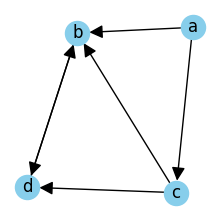

In [51]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
nodes = list(G0.keys())
edges = [(u,v) for u in G0 for v in G0[u]]
   
G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)      

plt.figure(figsize=(2, 2))
np.random.seed(7)
nx.draw(G, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)

Man kann das dict auch direct übergeben.

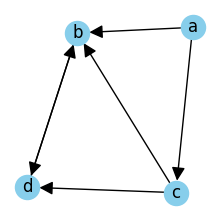

In [41]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
G = nx.DiGraph(G0)
plt.figure(figsize=(2, 2))
np.random.seed(7)
nx.draw(G, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)

Die Positionen können wir manuell setzen

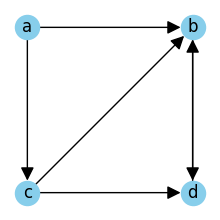

In [42]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
G = nx.DiGraph(G0)
pos = {'a':(0,1), 'c':(0,0), 'b':(1,1), 'd':(1,0)}
plt.figure(figsize=(2, 2))
nx.draw(G, pos, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)


#### Ungerichtete ungewichtete Graphen

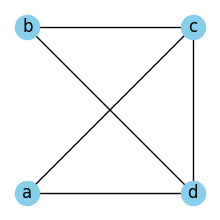

In [53]:
G0 = {
    'a': set('cd'),
    'b': set('cd'),
    'c': set('abd'),
    'd': set('acb')
}
G = nx.Graph(G0)
pos = {'a':(0,0), 'b':(0,1), 'c':(1,1), 'd':(1,0)}
plt.figure(figsize=(2, 2))
nx.draw(G, pos, with_labels=True, node_color='skyblue')

#### Gerichtete gewichtete Graphen

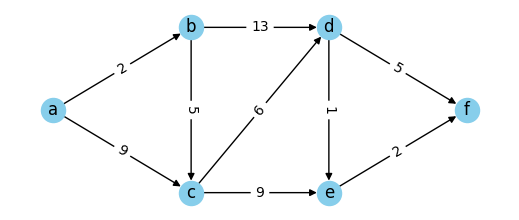

In [54]:
G0 = {
    'a': {'b': 2, 'c': 9},
    'b': {'c': 5, 'd': 13},
    'c': {'d': 6, 'e': 9},
    'd': {'e': 1, 'f': 5},
    'e': {'f': 2},
    'f': {}
}

G = nx.DiGraph()

for u, neighbors in G0.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)

#automatisches Layout
#pos = nx.spring_layout(G, seed=5)
#pos = nx.shell_layout(G)

pos = {'a':(0,1), 'b':(1,2), 'c':(1,0), 'd':(2,2), 'e':(2,0), 'f':(3,1)}

plt.figure(figsize=(5, 2))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue",
    arrows=True
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

#### Ungerichtete gewichtete Graphen

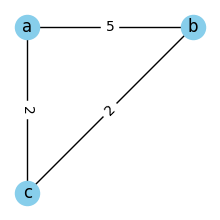

In [57]:
G0 = {
    'a': {'b': 5, 'c': 2},
    'b': {'a': 5, 'c': 2},
    'c': {'a': 2, 'b': 2},
}

G = nx.Graph()

for u, neighbors in G0.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)


pos = {'c':(0,0), 'a':(0,1), 'b':(1,1)}

plt.figure(figsize=(2, 2))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue"
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

#### Bäume

Die Funktion _layout berechnet rekursiv die Positionen der Baumknoten.

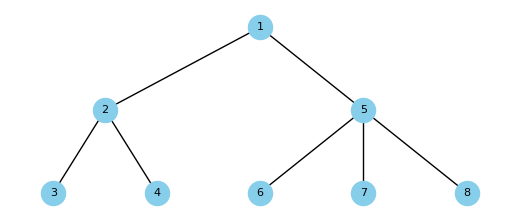

In [94]:
def anzahl_blaetter(G, node):
    children = G[node]
    if not children:
        return 1
    return sum(anzahl_blaetter(G, c) for c in children)

def tree_layout(G, root, x=0, y=0):
    pos = {}
    
    def _layout(node, x, y):
        children = G[node]
        width = anzahl_blaetter(G, node)
        pos[node] = (x, y)

        if children:
            start_x = x - width / 2
            current_x = start_x
            for child in children:
                w = anzahl_blaetter(G, child)
                child_x = current_x + w / 2
                _layout(child, child_x, y - 1)
                current_x += w

    _layout(root, x, y)
    return pos

G0 = {1: [2, 5], 2: [3, 4], 3: [], 4: [], 5: [6, 7, 8], 6: [], 7: [], 8: []}
G = nx.DiGraph(G0)
pos = tree_layout(G0, root=1)
plt.figure(figsize=(5, 2))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    arrows=False,
    font_size=8
)

plt.show()